## cos𝜽* calculation at a reco-level using AK4 jets instead of AK8 jets. 

In [54]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json

NanoAODSchema.warn_missing_crossrefs = False

In [55]:
# Datasets:
#/BulkGravToWW_narrow_M-*_13TeV-madgraph/*NanoAODv7*/NANOAODSIM
#/RSGravToWWToWlepWhad_width0p1_M-*_TuneCUETP8M1_13TeV-madgraph-pythia8/*NanoAODv3*/NANOAODSIM


# When having a large number of files it is useful to put the list on a separate file.
# import json

# with open("semileptonic_notebooks/samples.json", 'r') as sample_file:
#     fileset = json.load(sample_file)

# for sample in fileset:
#     print(sample)

# For now we are only testing on a limited number of files so they are just listed here
fileset = {
    'BulkGravToWW': {
        'files': {
            # M-1000 sample
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
        },
        'metadata': {
            'is_mc': True,
        },
    },
    'RSGravToWW': {
        'files': {
            'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv3/RSGravToWWToWlepWhad_width0p1_M-1200_TuneCUETP8M1_13TeV-madgraph-pythia8/NANOAODSIM/PUMoriond17_94X_mcRun2_asymptotic_v3-v1/60000/4442437A-52BB-E811-A8DA-90E2BACC5EEC.root': "Events",
          },
        'metadata': {
            'is_mc': 'Events',
        },
    }
}

In [56]:
# This step takes some time because it is loading the events
test_dataset_bulk = 'BulkGravToWW'
events = NanoEventsFactory.from_root(
    fileset[test_dataset_bulk]['files'],
    entry_stop = 1000,
    metadata = fileset[test_dataset_bulk]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()

# test_dataset_rs = 'RSGravToWW'
# events = NanoEventsFactory.from_root(
#     fileset[test_dataset_rs]['files'],
#     entry_stop =1000,
#     metadata = fileset[test_dataset_rs]['metadata'],
#     schemaclass = NanoAODSchema,
#     delayed = False,
# ).events()

### --- *Step 1: Tight Lepton Selection* ----

In [57]:
muons = events.Muon
electrons = events.Electron

# -- Tight lepton selection --
tight_muon = muons[
    (muons.pt > 30) & 
    (abs(muons.eta) < 2.4) & 
    (muons.tightId)
]

print(len(ak.flatten(tight_muon)), 'out of' ,len(ak.flatten(muons)), 'muons pass the tight selection')

tight_electron = electrons[
    (electrons.pt > 35) & 
    (abs(electrons.eta) < 2.4) & 
    (electrons.cutBased >= 3)
]

print(len(ak.flatten(tight_electron)), 'out of' ,len(ak.flatten(electrons)), 'electrons pass the tight selection')


# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_muon.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(tight_electron.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

266 out of 724 muons pass the tight selection
195 out of 897 electrons pass the tight selection


In [62]:
# -- Merge leptons into a single collection --
tight_leptons = ak.with_name(
    ak.concatenate([tight_muon, tight_electron], axis=1),
    "PtEtaPhiMCandidate"
)
print(len(ak.flatten(tight_leptons)))

461


In [59]:
# Thresholds
electron_pt_threshold = 40
muon_pt_threshold = 40
pt_miss_threshold = 40

# Tight leptons (using previous selections)
muons_tight = tight_muons[tight_muons.pt > muon_pt_threshold]
electrons_tight = tight_electrons[tight_electrons.pt > electron_pt_threshold]

# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events passed the tight lepton selection and loose veto.")

304 events passed the tight lepton selection and loose veto.


### --- *Step 2: AK4 jet cleaning* ---

In [61]:
# -- Select AK4 jets --
# --- Step 2: Select AK4 jets from events_selected ---
jets = events_selected.Jet

# Apply basic quality cuts
ak4_jets = jets[
    (jets.pt > 30) &
    (abs(jets.eta) < 2.4) &
    (jets.jetId >= 2)
]

print(f"Total AK4 jets before cleaning: {ak.count(ak.flatten(ak4_jets))}")

# --- ΔR Cleaning from tight lepton ---
# Pair each jet with the leading tight lepton
pairs = ak.cartesian({"jet": ak4_jets, "lep": tight_lep}, nested=True, axis=1)

# Compute ΔR between each jet and the leading lepton
delta_eta = pairs.jet.eta - pairs.lep.eta
delta_phi = (pairs.jet.phi - pairs.lep.phi + np.pi) % (2 * np.pi) - np.pi
delta_r = np.sqrt(delta_eta**2 + delta_phi**2)

# Keep jets with ΔR > 0.4
ak4_jets_clean = pairs.jet[delta_r > 0.4]

print(f"Total AK4 jets after cleaning: {ak.count(ak.flatten(ak4_jets_clean))}")


IndexError: cannot slice ListArray (of length 304) with array(0): index out of range while attempting to get index 0 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-44/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_next_at.cpp#L21)

In [18]:
# Check available FatJet fields
print(ak.fields(events_sl.FatJet))

['area', 'btagCMVA', 'btagCSVV2', 'btagDDBvL', 'btagDDBvL_noMD', 'btagDDCvB', 'btagDDCvB_noMD', 'btagDDCvL', 'btagDDCvL_noMD', 'btagDeepB', 'btagHbb', 'deepTagMD_H4qvsQCD', 'deepTagMD_HbbvsQCD', 'deepTagMD_TvsQCD', 'deepTagMD_WvsQCD', 'deepTagMD_ZHbbvsQCD', 'deepTagMD_ZHccvsQCD', 'deepTagMD_ZbbvsQCD', 'deepTagMD_ZvsQCD', 'deepTagMD_bbvsLight', 'deepTagMD_ccvsLight', 'deepTag_H', 'deepTag_QCD', 'deepTag_QCDothers', 'deepTag_TvsQCD', 'deepTag_WvsQCD', 'deepTag_ZvsQCD', 'eta', 'mass', 'msoftdrop', 'n2b1', 'n3b1', 'phi', 'pt', 'rawFactor', 'tau1', 'tau2', 'tau3', 'tau4', 'lsf3', 'jetId', 'subJetIdx1', 'subJetIdx2', 'electronIdx3SJ', 'muonIdx3SJ', 'genJetAK8Idx', 'hadronFlavour', 'nBHadrons', 'nCHadrons', 'genJetAK8IdxG', 'subJetIdx1G', 'subJetIdx2G', 'subJetIdxG']


### --- Step 3: Remove AK8 Jet Overlap ---

In [20]:
# -- AK8 jets used for boosted W selection --
ak8_jets = events_sl.FatJet[
    (events_sl.FatJet.pt > 200) &
    (abs(events_sl.FatJet.eta) < 2.4) &
    (events_sl.FatJet.msoftdrop > 40)
]

# -- Build AK4–AK8 jet pairs per event --
ak4_ak8_pairs = ak.cartesian({"ak4": ak4_jets_clean, "ak8": ak8_jets}, nested=True, axis=1)

# -- Compute ΔR(AK4, AK8) --
delta_eta = ak4_ak8_pairs["ak4"].eta - ak4_ak8_pairs["ak8"].eta
delta_phi = (ak4_ak8_pairs["ak4"].phi - ak4_ak8_pairs["ak8"].phi + np.pi) % (2 * np.pi) - np.pi
delta_r = np.sqrt(delta_eta**2 + delta_phi**2)

# -- Keep AK4 jets with ΔR > 0.8 from all AK8 jets --
clean_mask = ak.all(delta_r > 0.8, axis=2)  # [n_events, n_ak4]
ak4_jets_clean = ak4_jets_clean[clean_mask]

### --- Step 4: Define Semi-Leptonic and Hadronic Categories Using AK4 Jets ---

In [41]:
# Recompute counts
n_ak4 = ak.num(ak4_jets_clean)
n_lep = ak.num(tight_leptons)

# Define masks properly (but don't apply yet!)
mask_sl = (n_lep == 1) & (n_ak4 >= 2)
mask_had = (n_lep == 0) & (n_ak4 >= 4)

# Step 2: Apply masks to all objects together to preserve alignment
ak4_jets_semilep = ak4_jets_clean[mask_sl]
tight_leptons_sl = tight_leptons[mask_sl]
ak4_jets_hadronic = ak4_jets_clean[mask_had]

# Step 3: Double check number of jets AFTER masking
ak4_jets_semilep = ak4_jets_semilep[ak.num(ak4_jets_semilep) >= 2]
ak4_jets_hadronic = ak4_jets_hadronic[ak.num(ak4_jets_hadronic) >= 4]

# Flatten to get a clean [event][jet] structure
ak4_jets_semilep = ak.flatten(ak4_jets_semilep, axis=1)
ak4_jets_hadronic = ak.flatten(ak4_jets_hadronic, axis=1)

# Sort the AK4 jets by pt descending in each event
ak4_jets_semilep = ak.sort(ak4_jets_semilep, axis=1, ascending=False)
ak4_jets_hadronic = ak.sort(ak4_jets_hadronic, axis=1, ascending=False)

ValueError: cannot use non-negative axis on a nested list structure of variable depth (negative axis counts from the leaves of the tree; non-negative from the root)

### --- Step 5: Extract Leading Jets for Each Category ---

In [38]:
# Extract leading jets
lead_ak4_sl = ak4_jets_semilep[:, 0]
sublead_ak4_sl = ak4_jets_semilep[:, 1]

lead_ak4_had = ak4_jets_hadronic[:, 0]
sublead_ak4_had = ak4_jets_hadronic[:, 1]
third_ak4_had = ak4_jets_hadronic[:, 2]
fourth_ak4_had = ak4_jets_hadronic[:, 3]

### --- Step 6: Plotting Jet Properties (pt, eta, mass) ---

In [27]:
lead_ak4_sl_flat = ak.flatten(lead_ak4_sl[ak.num(lead_ak4_sl) > 0])
lead_ak4_had_flat = ak.flatten(lead_ak4_had[ak.num(lead_ak4_had) > 0])
sublead_ak4_had_flat = ak.flatten(sublead_ak4_had[ak.num(sublead_ak4_had) > 0])

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_194/3733966699.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("AK4 Jet $\eta$")


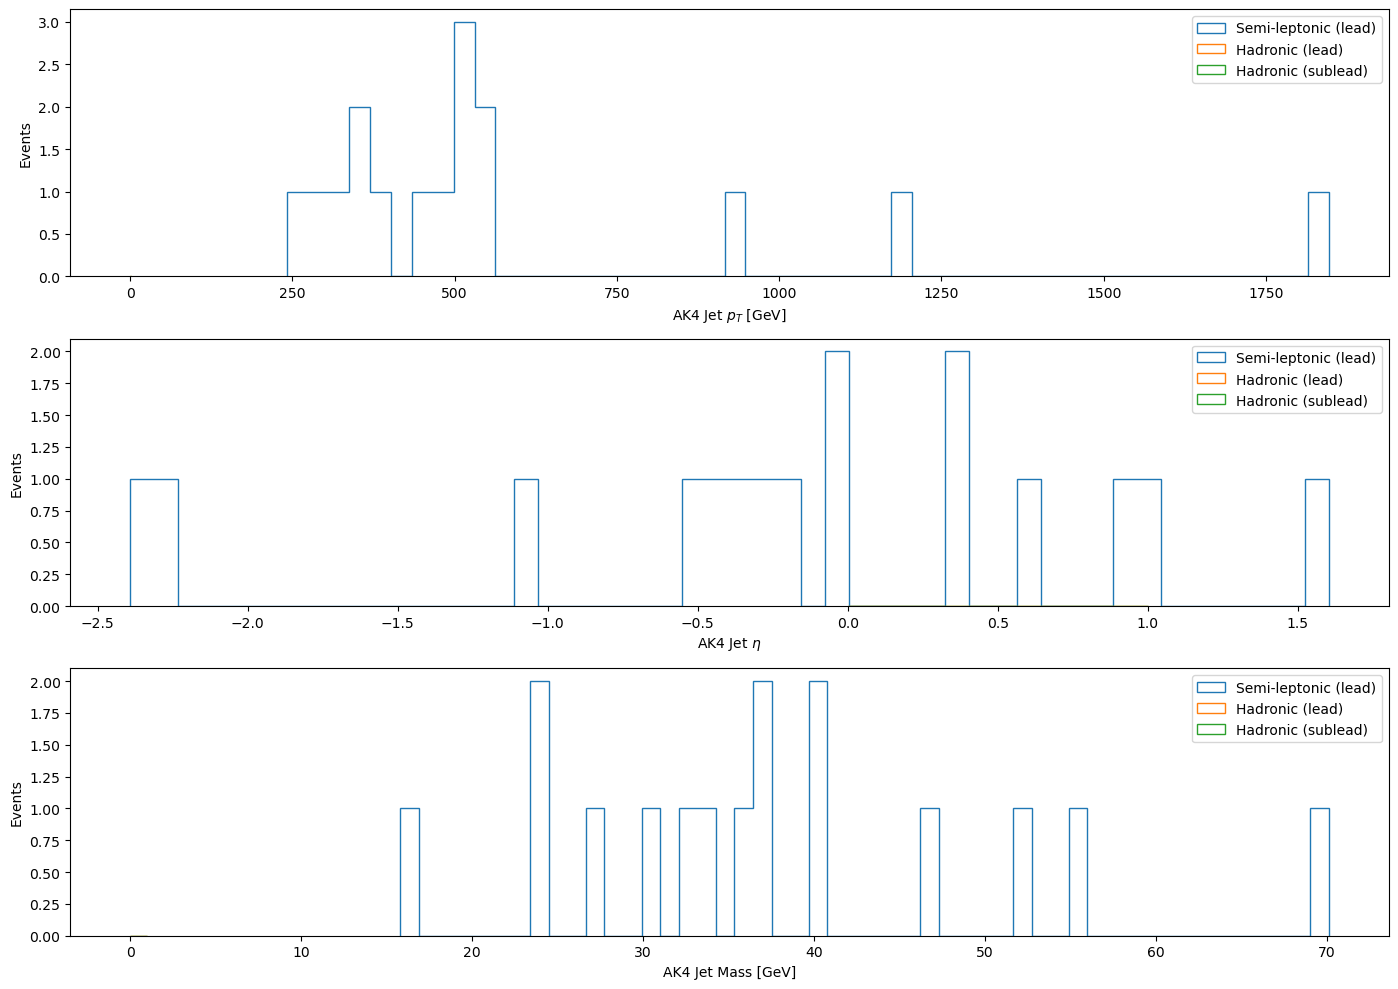

In [29]:
plt.figure(figsize=(14, 10))

# -- AK4 pt distributions --
plt.subplot(3, 1, 1)
plt.hist(ak.to_numpy(lead_ak4_sl_flat.pt), bins=50, histtype="step", label="Semi-leptonic (lead)")
plt.hist(ak.to_numpy(lead_ak4_had_flat.pt), bins=50, histtype="step", label="Hadronic (lead)")
plt.hist(ak.to_numpy(sublead_ak4_had_flat.pt), bins=50, histtype="step", label="Hadronic (sublead)")
plt.xlabel("AK4 Jet $p_T$ [GeV]")
plt.ylabel("Events")
plt.legend()

# -- AK4 eta distributions --
plt.subplot(3, 1, 2)
plt.hist(ak.to_numpy(lead_ak4_sl_flat.eta), bins=50, histtype="step", label="Semi-leptonic (lead)")
plt.hist(ak.to_numpy(lead_ak4_had_flat.eta), bins=50, histtype="step", label="Hadronic (lead)")
plt.hist(ak.to_numpy(sublead_ak4_had_flat.eta), bins=50, histtype="step", label="Hadronic (sublead)")
plt.xlabel("AK4 Jet $\eta$")
plt.ylabel("Events")
plt.legend()

# -- AK4 mass distributions --
plt.subplot(3, 1, 3)
plt.hist(ak.to_numpy(lead_ak4_sl_flat.mass), bins=50, histtype="step", label="Semi-leptonic (lead)")
plt.hist(ak.to_numpy(lead_ak4_had_flat.mass), bins=50, histtype="step", label="Hadronic (lead)")
plt.hist(ak.to_numpy(sublead_ak4_had_flat.mass), bins=50, histtype="step", label="Hadronic (sublead)")
plt.xlabel("AK4 Jet Mass [GeV]")
plt.ylabel("Events")
plt.legend()

plt.tight_layout()
plt.show()